In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

print("🔍 Đang truy tìm đường dẫn file trong hệ thống Kaggle...\n")

# Quét toàn bộ thư mục Input để tìm đường dẫn chính xác
path_trans = ""
path_id = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        if 'train_transaction.csv' in filename:
            path_trans = filepath
        elif 'train_identity.csv' in filename:
            path_id = filepath

print(f"Đã tìm thấy Transaction file: {path_trans}")
print(f"Đã tìm thấy Identity file: {path_id}\n")

print("⏳ Đang tải dữ liệu trực tiếp từ Kaggle server...")
# Tải dữ liệu
df_trans = pd.read_csv(path_trans)
df_id = pd.read_csv(path_id)

print("✅ Tải xong! Đang gộp dữ liệu...")
df = df_trans.merge(df_id, on='TransactionID', how='left')

print(f"🎯 Kích thước bộ dữ liệu tổng hợp: {df.shape[0]} dòng, {df.shape[1]} cột")
df.head(3)

🔍 Đang truy tìm đường dẫn file trong hệ thống Kaggle...

Đã tìm thấy Transaction file: /kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv
Đã tìm thấy Identity file: /kaggle/input/competitions/ieee-fraud-detection/train_identity.csv

⏳ Đang tải dữ liệu trực tiếp từ Kaggle server...
✅ Tải xong! Đang gộp dữ liệu...
🎯 Kích thước bộ dữ liệu tổng hợp: 590540 dòng, 434 cột


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import numpy as np

print("--- BƯỚC 1: KỸ NGHỆ ĐẶC TRƯNG CHUYÊN SÂU ---")
print("⏳ Đang tạo các đặc trưng ma thuật & hành vi...")

# BẮT BUỘC: Sắp xếp theo thời gian để tính toán lịch sử chính xác
df = df.sort_values('TransactionDT').reset_index(drop=True)

# 1. Đặc trưng về số tiền
df['TransactionAmt_Decimal'] = ((df['TransactionAmt'] - np.floor(df['TransactionAmt'])) * 1000).astype(int)

# 2. Đặc trưng Tần suất (Frequency Encoding)
columns_to_count = ['card1', 'card2', 'addr1', 'P_emaildomain']
for col in columns_to_count:
    if col in df.columns:
        freq_dict = df[col].value_counts().to_dict()
        df[f'{col}_freq'] = df[col].map(freq_dict)

# 3. Đặc trưng Hành vi: Lịch sử chi tiêu của thẻ
if 'card1' in df.columns:
    df['card1_TransactionAmt_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
    df['card1_TransactionAmt_std'] = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)
    df['TransactionAmt_to_mean_card1'] = df['TransactionAmt'] / (df['card1_TransactionAmt_mean'] + 1e-5)

# 4. Đặc trưng UID & Vận tốc quẹt thẻ
print("🔗 Đang tạo Định danh và tính toán Vận tốc quẹt thẻ...")
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
df['uid_TransactionAmt_mean'] = df.groupby('uid')['TransactionAmt'].transform('mean')
df['uid_freq'] = df.groupby('uid')['TransactionID'].transform('count')

# Tính thời gian giữa 2 lần quẹt (Vận tốc)
df['uid_TimeDelta'] = df.groupby('uid')['TransactionDT'].diff().fillna(-1)

print(f"✅ Hoàn tất Feature Engineering! Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột")

--- BƯỚC 1: KỸ NGHỆ ĐẶC TRƯNG CHUYÊN SÂU ---
⏳ Đang tạo các đặc trưng ma thuật & hành vi...
🔗 Đang tạo Định danh và tính toán Vận tốc quẹt thẻ...
✅ Hoàn tất Feature Engineering! Kích thước: 590540 dòng, 446 cột


--- BƯỚC 1.5: SIÊU KHÁM PHÁ DỮ LIỆU ĐA CHIỀU (BẢN VÁ LỖI TRẮNG BIỂU ĐỒ) ---


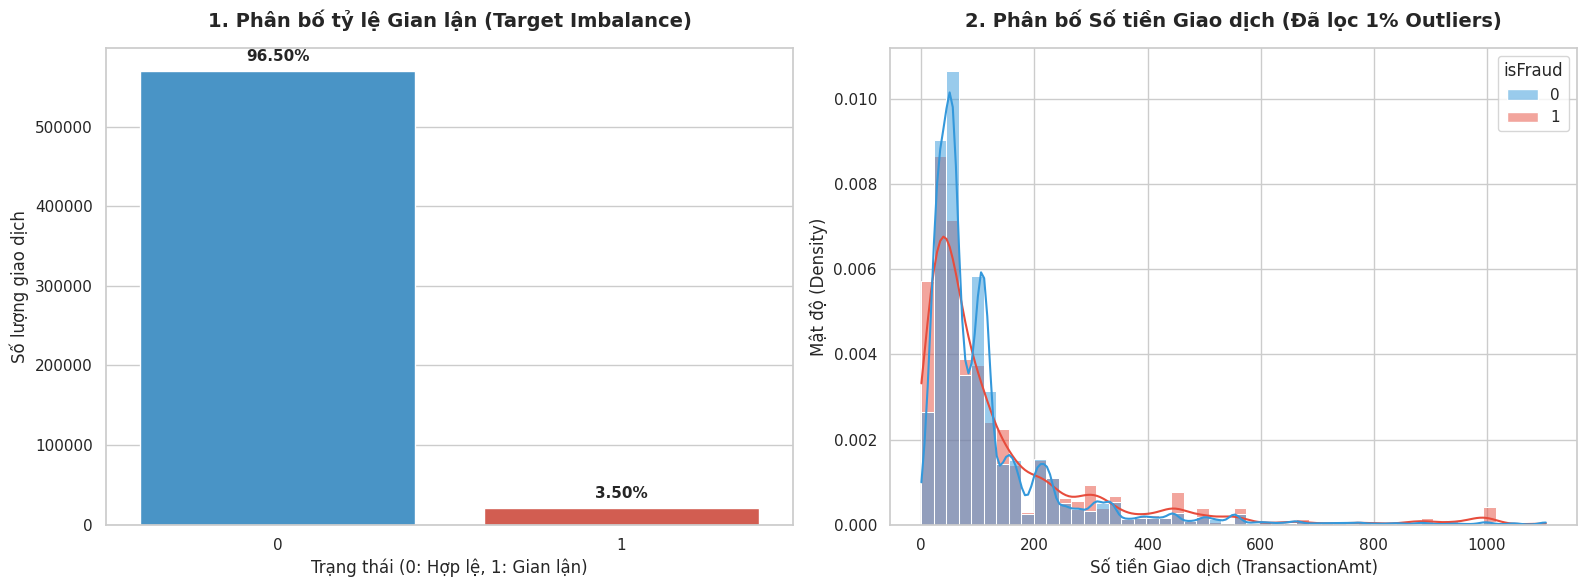

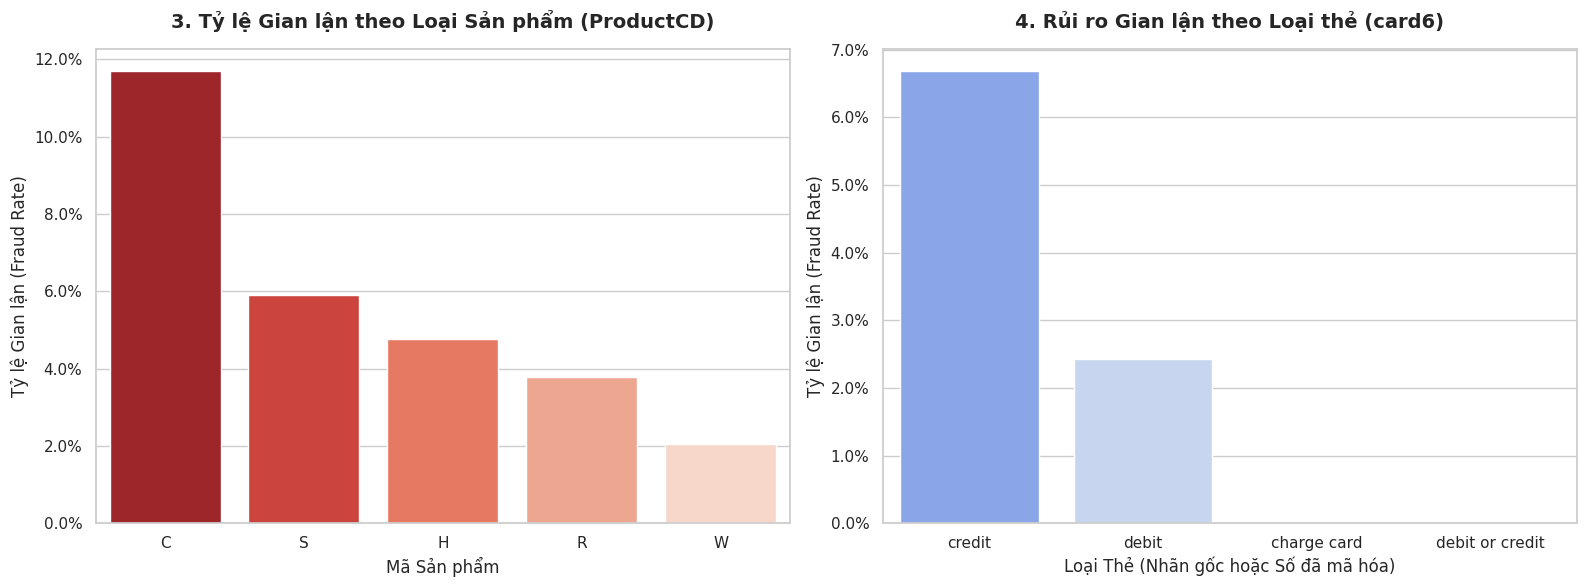

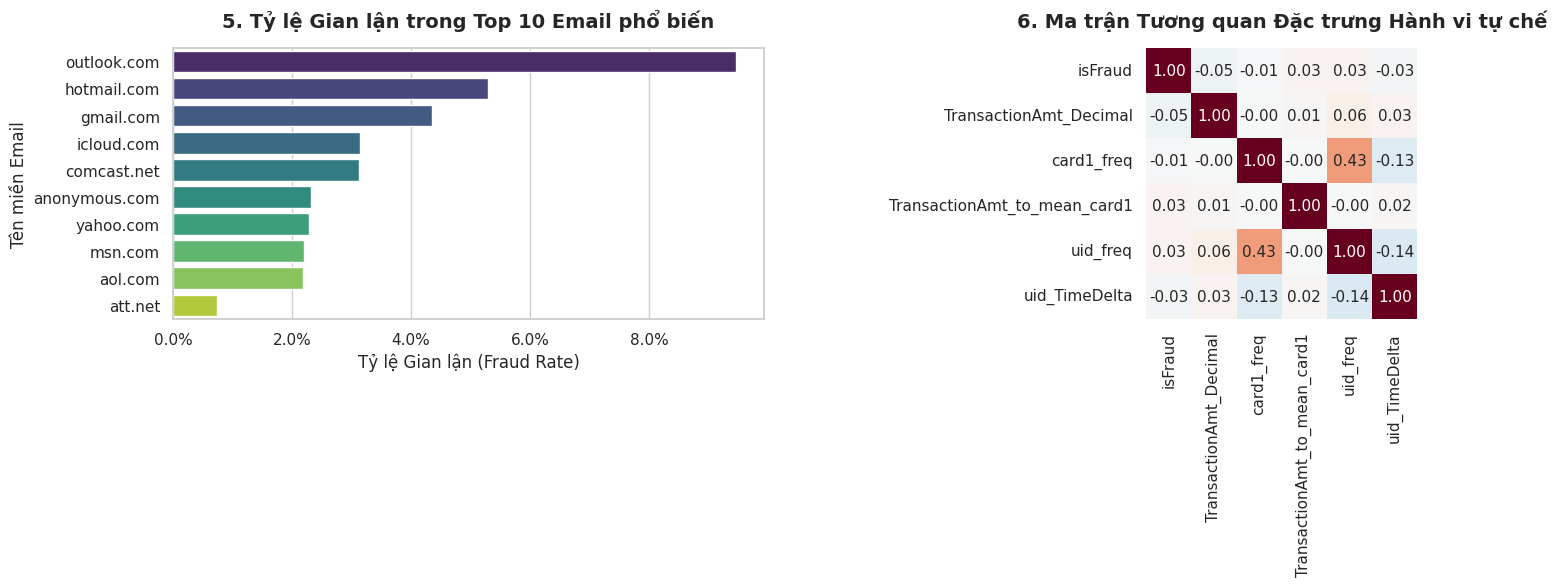

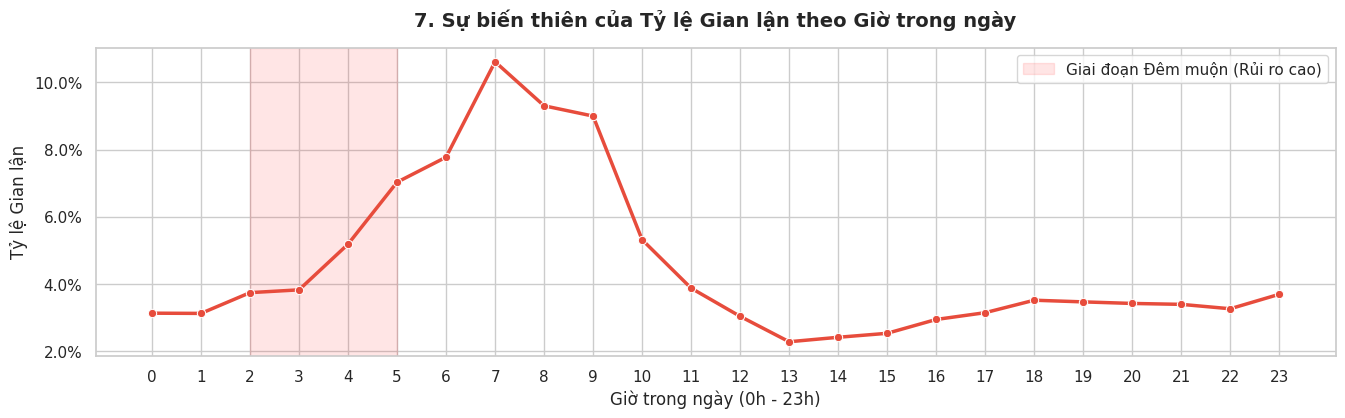

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- BƯỚC 1.5: SIÊU KHÁM PHÁ DỮ LIỆU ĐA CHIỀU (BẢN VÁ LỖI TRẮNG BIỂU ĐỒ) ---")

# Cấu hình giao diện chuẩn báo cáo
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==========================================================
# KHÍA CẠNH 1 & 2: TỔNG QUAN SỰ MẤT CÂN BẰNG & SỐ TIỀN GIAO DỊCH
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Phân bố tỷ lệ Gian lận
total = len(df)
ax1 = sns.countplot(x='isFraud', data=df, palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('1. Phân bố tỷ lệ Gian lận (Target Imbalance)', fontweight='bold', pad=15)
axes[0].set_xlabel('Trạng thái (0: Hợp lệ, 1: Gian lận)')
axes[0].set_ylabel('Số lượng giao dịch')

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{100 * height / total:.2f}%',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# 2. Phân bố số tiền giao dịch
q99 = df['TransactionAmt'].quantile(0.99)
df_filtered = df[df['TransactionAmt'] <= q99]
sns.histplot(data=df_filtered, x='TransactionAmt', hue='isFraud', 
             bins=50, kde=True, stat='density', common_norm=False, 
             palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.5, ax=axes[1])
axes[1].set_title('2. Phân bố Số tiền Giao dịch (Đã lọc 1% Outliers)', fontweight='bold', pad=15)
axes[1].set_xlabel('Số tiền Giao dịch (TransactionAmt)')
axes[1].set_ylabel('Mật độ (Density)')

plt.tight_layout()
plt.show()

# ==========================================================
# KHÍA CẠNH 3 & 4: PHÂN TÍCH RỦI RO THEO DANH MỤC & THẺ GIAO DỊCH
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Tỷ lệ gian lận theo Loại sản phẩm (ProductCD)
product_fraud = df.groupby('ProductCD')['isFraud'].mean().reset_index().sort_values('isFraud', ascending=False)
sns.barplot(data=product_fraud, x='ProductCD', y='isFraud', palette='Reds_r', ax=axes[0])
axes[0].set_title('3. Tỷ lệ Gian lận theo Loại Sản phẩm (ProductCD)', fontweight='bold', pad=15)
axes[0].set_xlabel('Mã Sản phẩm')
axes[0].set_ylabel('Tỷ lệ Gian lận (Fraud Rate)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}%'.format(y*100)))

# 4. Tỷ lệ gian lận theo Loại thẻ (card6) - ĐÃ SỬA LỖI TỰ ĐỘNG THÍCH ỨNG
if 'card6' in df.columns:
    # Lấy top các loại thẻ phổ biến nhất đang có trong dữ liệu hiện tại (chữ hoặc số đều chạy được)
    top_cards = df['card6'].value_counts().head(4).index
    card_df = df[df['card6'].isin(top_cards)]
    
    card_fraud = card_df.groupby('card6')['isFraud'].mean().reset_index().sort_values('isFraud', ascending=False)
    sns.barplot(data=card_fraud, x='card6', y='isFraud', palette='coolwarm', ax=axes[1])
    axes[1].set_title('4. Rủi ro Gian lận theo Loại thẻ (card6)', fontweight='bold', pad=15)
    axes[1].set_xlabel('Loại Thẻ (Nhãn gốc hoặc Số đã mã hóa)')
    axes[1].set_ylabel('Tỷ lệ Gian lận (Fraud Rate)')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}%'.format(y*100)))

plt.tight_layout()
plt.show()

# ==========================================================
# KHÍA CẠNH 5 & 6: RỦI RO THEO EMAIL VÀ ĐỘ TƯƠNG QUAN ĐẶC TRƯNG TỰ CHẾ
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5. Phân tích Nhà cung cấp Email (P_emaildomain) - Top 10 phổ biến nhất
if 'P_emaildomain' in df.columns:
    top_emails = df['P_emaildomain'].value_counts().head(10).index
    email_df = df[df['P_emaildomain'].isin(top_emails)]
    email_fraud = email_df.groupby('P_emaildomain')['isFraud'].mean().reset_index().sort_values('isFraud', ascending=False)
    
    sns.barplot(data=email_fraud, y='P_emaildomain', x='isFraud', palette='viridis', ax=axes[0])
    axes[0].set_title('5. Tỷ lệ Gian lận trong Top 10 Email phổ biến', fontweight='bold', pad=15)
    axes[0].set_xlabel('Tỷ lệ Gian lận (Fraud Rate)')
    axes[0].set_ylabel('Tên miền Email')
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}%'.format(x*100)))

# 6. Ma trận tương quan của các Đặc trưng Ma thuật (Magic Features Correlation)
magic_cols = ['isFraud', 'TransactionAmt_Decimal', 'card1_freq', 'TransactionAmt_to_mean_card1', 'uid_freq', 'uid_TimeDelta']
available_magic = [c for c in magic_cols if c in df.columns]

corr_matrix = df[available_magic].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar=False, ax=axes[1])
axes[1].set_title('6. Ma trận Tương quan Đặc trưng Hành vi tự chế', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# ==========================================================
# KHÍA CẠNH PHỤ (DÒNG THỜI GIAN): XU HƯỚNG GIAN LẬN THEO GIỜ
# ==========================================================
if 'TransactionDT' in df.columns:
    df['Temp_Hour'] = np.floor(df['TransactionDT'] / 3600) % 24
elif 'Transaction_Hour' in df.columns:
    df['Temp_Hour'] = df['Transaction_Hour']
else:
    df['Temp_Hour'] = None

if df['Temp_Hour'] is not None:
    hourly_fraud = df.groupby('Temp_Hour')['isFraud'].agg(['count', 'mean']).reset_index()

    plt.figure(figsize=(16, 4))
    ax3 = sns.lineplot(data=hourly_fraud, x='Temp_Hour', y='mean', marker='o', color='#e74c3c', linewidth=2.5)
    plt.title('7. Sự biến thiên của Tỷ lệ Gian lận theo Giờ trong ngày', fontweight='bold', pad=15)
    plt.xlabel('Giờ trong ngày (0h - 23h)')
    plt.ylabel('Tỷ lệ Gian lận')
    plt.xticks(range(0, 24))
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1f}%'.format(y*100)))

    plt.axvspan(2, 5, color='red', alpha=0.1, label='Giai đoạn Đêm muộn (Rủi ro cao)')
    plt.legend()
    plt.show()

    if 'TransactionDT' in df.columns:
        df = df.drop(columns=['Temp_Hour'])

In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("--- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---")

# Kiểm tra xem cột còn tồn tại không (chống lỗi khi chạy Cell này nhiều lần)
if 'TransactionDT' in df.columns:
    print("⏳ Đang trích xuất thời gian và dọn dẹp các cột thừa...")
    # 1. Trích xuất giờ và ngày
    df['Transaction_Hour'] = np.floor(df['TransactionDT'] / 3600) % 24
    df['Transaction_DayOfWeek'] = np.floor((df['TransactionDT'] / (3600 * 24)) - 1) % 7
    
    # Xóa các cột không mang tính dự đoán (uid chỉ dùng tạo đặc trưng)
    drop_cols = ['TransactionID', 'TransactionDT', 'uid']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
else:
    print("⏳ Các cột thời gian đã được xử lý từ trước rồi, bỏ qua bước trích xuất!")

# 2. Mã hóa Label Encoding
print("🔤 Đang mã hóa Categorical thành số...")
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('Unknown'))

print("🛡️ Giữ nguyên toàn bộ NaN để mô hình Cây tự xử lý...")
print(f"✅ Hoàn tất Tiền xử lý! Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột")

--- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---
⏳ Đang trích xuất thời gian và dọn dẹp các cột thừa...
🔤 Đang mã hóa Categorical thành số...
🛡️ Giữ nguyên toàn bộ NaN để mô hình Cây tự xử lý...
✅ Hoàn tất Tiền xử lý! Kích thước: 590540 dòng, 445 cột


In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import numpy as np
import gc

print("--- BƯỚC 3: HUẤN LUYỆN TIME-SERIES ENSEMBLE (LGBM + XGB) ---")

X = df.drop(columns=['isFraud'])
y = df['isFraud']

cat_features = ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P_emaildomain', 'R_emaildomain']
cat_cols = [col for col in cat_features if col in X.columns]

n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# Mảng lưu kết quả Out-Of-Fold
oof_preds = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(tscv.split(X)):
    print(f"\n🚀 --- Bắt đầu Fold {fold + 1}/{n_splits} ---")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
    
    # --- 1. LIGHTGBM ---
    print("  -> Đang chạy LightGBM...")
    model_lgb = lgb.LGBMClassifier(
        n_estimators=1500, learning_rate=0.02, num_leaves=128, max_depth=-1,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3, random_state=42, n_jobs=-1
    )
    model_lgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric='auc', 
                  categorical_feature=cat_cols, callbacks=[lgb.early_stopping(100, verbose=False)])
    preds_lgb = model_lgb.predict_proba(X_valid)[:, 1]
    
    # --- 2. XGBOOST ---
    print("  -> Đang chạy XGBoost...")
    model_xgb = xgb.XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3, 
        tree_method='hist', eval_metric='auc', random_state=42, n_jobs=-1
    )
    model_xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    preds_xgb = model_xgb.predict_proba(X_valid)[:, 1]
    
    # --- ENSEMBLE KẾT QUẢ FOLD NÀY ---
    oof_preds[valid_idx] = (preds_lgb * 0.6) + (preds_xgb * 0.4)
    print(f"✅ Fold {fold + 1} AUC: {roc_auc_score(y_valid, oof_preds[valid_idx]):.5f}")
    
    del X_train, y_train, model_lgb, model_xgb; gc.collect()

--- BƯỚC 3: HUẤN LUYỆN TIME-SERIES ENSEMBLE (LGBM + XGB) ---

🚀 --- Bắt đầu Fold 1/3 ---
  -> Đang chạy LightGBM...
[LightGBM] [Info] Number of positive: 3888, number of negative: 143747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.132018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36196
[LightGBM] [Info] Number of data points in the train set: 147635, number of used features: 442
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.026335 -> initscore=-3.610160
[LightGBM] [Info] Start training from score -3.610160
  -> Đang chạy XGBoost...
✅ Fold 1 AUC: 0.90915

🚀 --- Bắt đầu Fold 2/3 ---
  -> Đang chạy LightGBM...
[LightGBM] [Info] Number of positive: 9894, number of negative: 285376
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.422204 seconds.
You can set `force_row_wise=true` to remove t

🏆 KẾT QUẢ ĐÁNH GIÁ CHUNG TOÀN HỆ THỐNG (OUT-OF-FOLD)
🌟 Tổng thể OOF AUC: 0.91572
🎯 Ngưỡng cắt F1 tối ưu: 0.2902 (F1-Score cao nhất: 0.5581)

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

      Hợp lệ       0.98      0.99      0.98    426130
    Gian lận       0.65      0.49      0.56     16775

    accuracy                           0.97    442905
   macro avg       0.81      0.74      0.77    442905
weighted avg       0.97      0.97      0.97    442905



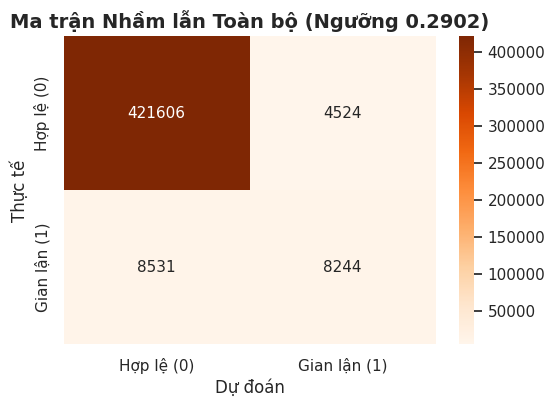

In [6]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("🏆 KẾT QUẢ ĐÁNH GIÁ CHUNG TOÀN HỆ THỐNG (OUT-OF-FOLD)")
print("="*50)

# Bỏ qua Fold đầu tiên (chưa được dự đoán OOF)
valid_indices = oof_preds > 0 
y_true_oof = y[valid_indices]
preds_oof = oof_preds[valid_indices]

print(f"🌟 Tổng thể OOF AUC: {roc_auc_score(y_true_oof, preds_oof):.5f}")

precisions, recalls, thresholds = precision_recall_curve(y_true_oof, preds_oof)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"🎯 Ngưỡng cắt F1 tối ưu: {best_threshold:.4f} (F1-Score cao nhất: {f1_scores[best_idx]:.4f})")

y_pred_optimal = (preds_oof >= best_threshold).astype(int)
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_true_oof, y_pred_optimal, target_names=['Hợp lệ', 'Gian lận']))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_true_oof, y_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Hợp lệ (0)', 'Gian lận (1)'], 
            yticklabels=['Hợp lệ (0)', 'Gian lận (1)'])
plt.title(f'Ma trận Nhầm lẫn Toàn bộ (Ngưỡng {best_threshold:.4f})', fontweight='bold')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()